# Jira Chatbot Historical Backtest

**Counterfactual question:**

> *Had this exact SugboDoc support chatbot existed when these historical Jira tickets were
> created, how many could it plausibly have handled **without human intervention**?*

This notebook is a **backtest**, not a production measurement. It runs historical ticket
summaries through the **unmodified production chatbot** (`core.bot.respond` — the same code
path the Streamlit widget and the FastAPI backend use) and has a **separate** LLM evaluator
judge each reply.

### Methodology at a glance

```
Historical ticket summary
        │            (resolution status withheld — no data leakage)
        ▼
core.bot.fresh_chat() + core.bot.respond()      ← PRODUCTION chatbot, unchanged
  same model (config.ANSWER_MODEL)
  same system prompt (knowledge.system_prompt)
  same retrieval setting (config.USE_RAG)
  same verification pass (config.VERIFY_ANSWERS)
        ▼
chatbot_response
        ▼
Separate strict evaluator (different model, its own prompt, never sees `resolved`)
        ▼
classification ∈ {FULL, PARTIAL, HUMAN}  +  reason
        ▼
Potential Ticket Deflection Rate = FULL / total evaluated
```

### Classifications

| Label | Meaning |
|---|---|
| **FULL** | Reply is correct, specific and self-sufficient — a reasonable support workflow could end here with no human. |
| **PARTIAL** | Reply gives real, on-topic help, but a human would still very likely need to step in. |
| **HUMAN** | Reply cannot close the ticket: needs access / a manual change / a decision / investigation, or is a refusal, vague, wrong or hallucinated. |

### What this number **is** and **is not**

* ✅ *"XX % **potential** ticket deflection, estimated by historical backtesting."*
* ❌ *"The chatbot automated XX % of support tickets."* — it never ran in production on these tickets; the evaluator is an LLM judging an LLM; ticket summaries are a lossy proxy for the real conversation.

### Limitations (read before quoting any figure)

1. **Counterfactual.** No real users, no follow-up turns, no back-and-forth. A one-line summary is not the full ticket thread.
2. **LLM evaluator.** Section 8 samples the evaluator against human labels; treat the headline number with the agreement rate attached.
3. **Knowledge-base drift.** The bot answers from *today's* docs, not the docs as they were when each ticket was filed.
4. **`historical_resolved` ≠ ground truth for deflection.** A ticket a human resolved may still have been chatbot-deflectable, and vice-versa. Section 7 Graph 3 is exploratory only.

## Section 2 — Imports & Configuration

In [11]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

# --- make the project importable when Jupyter's CWD is evaluation/ ------------
ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import config                                   # noqa: E402  (project root)
from core import knowledge                      # noqa: E402
from evaluation import backtest as bt           # noqa: E402

try:
    import matplotlib.pyplot as plt             # noqa: E402
    import seaborn as sns                       # noqa: E402
    sns.set_theme(style="whitegrid")
    HAVE_PLOTS = True
except ImportError:
    HAVE_PLOTS = False
    print("matplotlib/seaborn not installed — run:  pip install -r requirements-eval.txt")

pd.set_option("display.max_colwidth", 140)

### Run configuration

`CHATBOT_MODEL` is **read from `config`, never set here** — the backtest must use the exact
production model. Only the evaluator and the batch/rate-limit knobs are tunable.

In [12]:
RUN_ID          = datetime.now().strftime("backtest-%Y%m%d-%H%M")
CHATBOT_MODEL   = config.ANSWER_MODEL          # READ-ONLY mirror of production
# Separate judge. Default config.JUDGE_MODEL is gemini-pro-latest; overridden here to
# gemini-flash-latest because pro-latest's free-tier daily quota is exhausted. A flash
# judge is weaker and closer to the answer model's family — recorded in summary_metrics.json.
EVALUATOR_MODEL = "gemini-flash-latest"
BATCH_SIZE      = 50                           # chatbot phase: persist every N tickets
EVAL_BATCH_SIZE = 15                           # evaluator: tickets judged per LLM call
EVALUATOR_TEMPERATURE = 0.0
MAX_WORKERS     = 1                            # 1 = strictly sequential (rate-limit safe)
LIMIT           = None                         # e.g. 25 for a smoke test; None = all
TICKETS_PATH    = None                         # None -> data/jira_tickets.csv else .sample

cfg = bt.BacktestConfig(
    run_id=RUN_ID,
    evaluator_model=EVALUATOR_MODEL,
    batch_size=BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    evaluator_temperature=EVALUATOR_TEMPERATURE,
    max_workers=MAX_WORKERS,
    limit=LIMIT,
)

print("Run ID          :", RUN_ID)
print("Chatbot model   :", CHATBOT_MODEL, "  (production — not overridable)")
print("Evaluator model :", EVALUATOR_MODEL)
print("LLM backend     :", config.LLM_BACKEND, " | RAG:", config.USE_RAG,
      " | verify pass:", config.VERIFY_ANSWERS)
print("Knowledge base  :", config.DOCS_PATH.name,
      f"({len(knowledge.load_docs()):,} chars, {len(knowledge.content_sections())} sections)")
print("Started (UTC)   :", cfg.started_at)

Run ID          : backtest-20260907-1142
Chatbot model   : gemini-3.1-flash-lite   (production — not overridable)
Evaluator model : gemini-flash-latest
LLM backend     : gemini  | RAG: False  | verify pass: True
Knowledge base  : SugboDoc-Documentation.md (30,757 chars, 64 sections)
Started (UTC)   : 2026-09-07T03:42:06+00:00


> **Quota note.** The **chatbot phase** costs ~**2 Gemini calls per ticket** (answer +
> verification pass) and is irreducible — the backtest must run tickets one at a time to
> match production. The **evaluator phase** is batched: ~`ceil(N / EVAL_BATCH_SIZE)` calls
> total. On the Gemini free tier (small per-model daily cap) run in stages: set `LIMIT`,
> execute Sections 5–6, come back tomorrow. Results are appended to `evaluation/results/`
> and **re-running skips finished tickets** — nothing is lost or repeated. To rehearse the
> whole flow for free, restart the kernel after
> `import os; os.environ["LLM_BACKEND"] = "mock"` (the mock cannot act as the judge, so
> every ticket comes back `HUMAN` — plumbing only).

## Section 2b — Parse & filter the raw Jira export

The raw export `jira_tickets_history.csv` is product **user stories**, each summary shaped
like `{Subject}: As a {Type}, {Description}`. This cell splits those three fields out with
pure pandas + regex (no LLM), keeps only the roles in `KEEP_ROLES`, and writes
`jira_tickets_history-filtered.csv`. Inspect the kept/dropped breakdown, then let Section 3
load the filtered file.

In [13]:
import re  # noqa: E402

RAW_PATH   = bt.DATA_DIR / "jira_tickets_history.csv"
KEEP_ROLES = ["staff member", "admin", "doctor", "user"]   # Type must contain one of these

raw = pd.read_csv(RAW_PATH)
print(f"raw export: {len(raw)} rows, columns = {list(raw.columns)}")
display(raw.head())

# Summary is always  "{Subject}: As a {Type}, {Description}"
PATTERN = re.compile(
    r"^\s*(?P<Subject>.+?):\s*[Aa]s an?\s+(?P<Type>.+?),\s*(?P<Description>.+?)\s*$",
    re.DOTALL,
)
parsed = raw["Summary"].str.extract(PATTERN)
df = pd.concat([raw, parsed], axis=1)
df["Type_norm"] = df["Type"].str.strip().str.lower()

unparsed = df["Subject"].isna()
print(f"\nrows NOT matching '{{Subject}}: As a {{Type}}, {{Description}}': {unparsed.sum()}")
if unparsed.any():
    display(df.loc[unparsed, ["Issue id", "Summary"]])

role_re = "|".join(re.escape(r) for r in KEEP_ROLES)
keep = df["Type_norm"].str.contains(role_re, na=False)

print(f"\nKEPT  ({keep.sum()} rows) — Type breakdown:")
print(df.loc[keep, "Type_norm"].value_counts().to_string())
print(f"\nDROPPED  ({(~keep).sum()} rows) — Type breakdown:")
print(df.loc[~keep, "Type_norm"].value_counts(dropna=False).to_string())

filtered = df[keep].copy()
FILTERED_PATH = RAW_PATH.with_name(RAW_PATH.stem + "-filtered" + RAW_PATH.suffix)
filtered.to_csv(FILTERED_PATH, index=False)
print(f"\nwrote {FILTERED_PATH.name}  ({len(filtered)} rows, columns = {list(filtered.columns)})")

# Section 3 loads this. NOTE: load_tickets() still feeds the chatbot the full `Summary`
# string. If you'd rather it see only the parsed `Description`, say so and I'll switch it.
TICKETS_PATH = FILTERED_PATH

raw export: 50 rows, columns = ['Issue Type', 'Issue id', 'Summary', 'Status', 'Resolution']


,Issue Type,Issue id,Summary,Status,Resolution
0,Story,17973,"Inventory Item Charge: As a Staff member, I want to modify charges that were originally created from an inventory item, so that pricing ...",Done,Done
1,Story,17404,"Encounter List: As a Staff member, I want to search and track encounters by Encounter Number with more flexible search options, so that ...",Done,Done
2,Story,17206,"Financial Dashboard Revamp: As an Admin, I want a high-level view of total revenue and operating expenses across all connected healthcar...",Done,Done
3,Story,16504,"Patient Appointment Actions: As a Patient, I want enhanced appointment actions and a dedicated appointment detail view, so that I can ma...",Done,Done
4,Story,16304,"Service Request Notifications: As a Patient, I want improved Service Request email and SMS templates that include the practitioner, faci...",Done,Done



rows NOT matching '{Subject}: As a {Type}, {Description}': 0

KEPT  (33 rows) — Type breakdown:
Type_norm
staff member                                           18
admin                                                   4
user                                                    3
doctor                                                  1
facility staff member                                   1
accountant or finance user                              1
company user                                            1
facility admin                                          1
new user opening the patient app for the first time     1
user without the required access                        1
administrator                                           1

DROPPED  (17 rows) — Type breakdown:
Type_norm
patient                    12
healthcare practitioner     1
patient guest               1
guest                       1
practitioner                1
developer                   1

wrote jira_tickets_history

## Section 3 — Load Historical Jira Tickets

In [14]:
tickets = bt.load_tickets(TICKETS_PATH)

if tickets.attrs.get("is_sample"):
    print("⚠  Using the bundled SAMPLE dataset (evaluation/data/jira_tickets.sample.csv).")
    print("   Drop your real export at evaluation/data/jira_tickets.csv and re-run this cell.")
    print("   Required columns: ticket_id, summary   (resolved optional).\n")

report = bt.validate_tickets(tickets)
print(json.dumps(report, indent=2))

{
  "rows": 33,
  "unique_ticket_ids": 33,
  "duplicate_ticket_ids": 0,
  "blank_summaries": 0,
  "blank_ticket_ids": 0,
  "columns": [
    "issue_type",
    "ticket_id",
    "summary",
    "historical_status",
    "historical_resolved",
    "Subject",
    "Type",
    "Description",
    "Type_norm"
  ],
  "historical_resolved_counts": {
    "True": 33
  },
  "potential_leak_columns": [],
  "historical_status_counts": {
    "Done": 33
  }
}


In [15]:
# Data-quality gate
assert report["blank_ticket_ids"] == 0, "some tickets have no id"
assert report["blank_summaries"] == 0, "some tickets have no summary"
assert report["duplicate_ticket_ids"] == 0, "duplicate ticket_ids — dedupe first"
assert not report["potential_leak_columns"], \
    f"drop outcome columns before the bot sees them: {report['potential_leak_columns']}"
print("data validation passed —", report["rows"], "tickets")
tickets.head()

data validation passed — 33 tickets


,issue_type,ticket_id,summary,historical_status,historical_resolved,Subject,Type,Description,Type_norm
0,Story,17973,"Inventory Item Charge: As a Staff member, I want to modify charges that were originally created from an inventory item, so that pricing ...",Done,True,Inventory Item Charge,Staff member,"I want to modify charges that were originally created from an inventory item, so that pricing corrections don't require deleting and rec...",staff member
1,Story,17404,"Encounter List: As a Staff member, I want to search and track encounters by Encounter Number with more flexible search options, so that ...",Done,True,Encounter List,Staff member,"I want to search and track encounters by Encounter Number with more flexible search options, so that I can locate a specific encounter q...",staff member
2,Story,17206,"Financial Dashboard Revamp: As an Admin, I want a high-level view of total revenue and operating expenses across all connected healthcar...",Done,True,Financial Dashboard Revamp,Admin,"I want a high-level view of total revenue and operating expenses across all connected healthcare facilities, so that I can monitor finan...",admin
3,Story,16034,"Invoice Report Export: As a User, I want to apply filters before exporting, so that I only export the invoices I need.",Done,True,Invoice Report Export,User,"I want to apply filters before exporting, so that I only export the invoices I need.",user
4,Story,15967,"Appointment Reschedule: As a Doctor, I want to reschedule appointments from any tab and from the off-canvas panel, so that I don't have ...",Done,True,Appointment Reschedule,Doctor,"I want to reschedule appointments from any tab and from the off-canvas panel, so that I don't have to navigate to a specific view to mak...",doctor


## Section 4 — Inspect the Dataset

In [16]:
n = len(tickets)
print(f"Total tickets: {n}")
if "historical_resolved" in tickets.columns:
    vc = tickets["historical_resolved"].value_counts(dropna=False)
    for k, v in vc.items():
        print(f"  historical_resolved = {str(k):9} : {v:4}  ({v/n:.1%})")

lengths = tickets["summary"].str.len()
print(f"\nSummary length (chars): min {lengths.min()}, median {int(lengths.median())}, "
      f"mean {lengths.mean():.0f}, max {lengths.max()}")

for col in ("issue_type", "priority", "category", "project"):
    if col in tickets.columns and tickets[col].str.len().gt(0).any():
        print(f"\n{col}:")
        print(tickets[col].value_counts().to_string())

Total tickets: 33
  historical_resolved = True      :   33  (100.0%)

Summary length (chars): min 118, median 186, mean 183, max 273

issue_type:
issue_type
Story    33


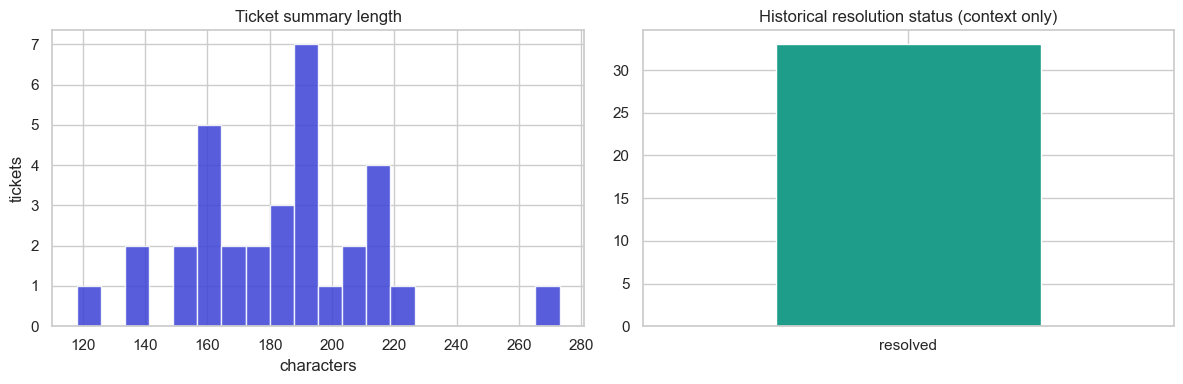

,ticket_id,summary
14,15506,"Appointment View: As a Facility Staff member, I want to see all upcoming appointments, my own upcoming appointments, and past appointmen..."
19,14749,"Appointment SMS Templates: As a Staff member, I want separate SMS templates for in-person and online appointments, so that patients rece..."
3,16034,"Invoice Report Export: As a User, I want to apply filters before exporting, so that I only export the invoices I need."
27,10529,"Case Note Enhancement - Expanded User Groups: As a Staff member, I want to create a case note for a wider range of user groups, includin..."
31,10525,"Insurance Claims Access Restriction: As a User without the required access, I should not be able to view the Claims module, so that insu..."


In [17]:
if HAVE_PLOTS:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(lengths, bins=20, color="#3b41d6", alpha=.85)
    ax[0].set_title("Ticket summary length"); ax[0].set_xlabel("characters"); ax[0].set_ylabel("tickets")
    if "historical_resolved" in tickets.columns:
        tickets["historical_resolved"].map({True: "resolved", False: "unresolved"}) \
            .value_counts().plot.bar(ax=ax[1], color=["#1f9d8b", "#e0a100"])
        ax[1].set_title("Historical resolution status (context only)")
        ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=0)
    fig.tight_layout(); plt.show()

# A few example summaries (no resolution shown — that is what the bot will see)
tickets[["ticket_id", "summary"]].sample(min(5, n), random_state=1)

> **Sanity-check the ticket type before reading too much into the result.** If most rows are
> product **user stories / feature requests** ("As an Admin, I want a financial dashboard…"),
> the chatbot *should* mostly return `HUMAN` — those are engineering work, not documentation
> questions. A low deflection rate then means *"most of this Jira backlog is not
> docs-answerable"*, which is a legitimate finding, not a failure of the bot.

## Section 5 — Run the Chatbot Backtest

Sends every ticket **summary** (and nothing else) through the production chatbot. Appends to
`evaluation/results/chatbot_responses.csv` after each batch. **Safe to interrupt** — re-run
to continue; a daily-quota error stops cleanly with partial results saved.

In [22]:
responses = bt.run_backtest(tickets, cfg)

if responses.empty:
    raise SystemExit("No responses yet (quota hit before the first batch?). "
                     "Wait for the Gemini daily quota to reset and re-run this cell — "
                     "finished tickets are cached and will be skipped.")

print(f"\n{len(responses)} / {len(tickets)} tickets have a chatbot response")

errored = bt._nonblank(responses.get("chatbot_error", pd.Series(dtype=str)))
if errored.any():
    print(f"⚠  {errored.sum()} tickets errored (kept, will count as HUMAN). Sample:")
    display(responses.loc[errored, ["ticket_id", "chatbot_error"]].head())

responses[["ticket_id", "summary", "chatbot_response", "chatbot_refused",
           "grounding_supported"]].head()

[backtest] 50 already done, 0 to process (model=gemini-3.1-flash-lite, batch=50, workers=1)

50 / 33 tickets have a chatbot response


,ticket_id,summary,chatbot_response,chatbot_refused,grounding_supported
0,17973,"Inventory Item Charge: As a Staff member, I want to modify charges that were originally created from an inventory item, so that pricing ...",I don't have enough information in my records to answer that. Please submit a support ticket.,True,True
1,17404,"Encounter List: As a Staff member, I want to search and track encounters by Encounter Number with more flexible search options, so that ...",I don't have enough information in my records to answer that. Please submit a support ticket.,True,True
2,17206,"Financial Dashboard Revamp: As an Admin, I want a high-level view of total revenue and operating expenses across all connected healthcar...",I don't have enough information in my records to answer that. Please submit a support ticket.,True,True
3,16504,"Patient Appointment Actions: As a Patient, I want enhanced appointment actions and a dedicated appointment detail view, so that I can ma...",I don't have enough information in my records to answer that. Please submit a support ticket.,True,True
4,16304,"Service Request Notifications: As a Patient, I want improved Service Request email and SMS templates that include the practitioner, faci...",I don't have enough information in my records to answer that. Please submit a support ticket.,True,True


### Section 5b — Why the chatbot refused (no LLM)

The refusal reply is a **fixed string** — the bot has no per-ticket "reason" field, and it
only ever refuses for one reason: *the request isn't covered by the SugboDoc docs*. The
evaluator will therefore label every refusal `HUMAN` by rule.

This cell quantifies *how far* each refused ticket is from anything documented — lexical
token overlap against every doc section, **zero API calls**. Low overlap = the request has
little in common with any documented procedure.

48 / 50 responses are refusals (each will be classified HUMAN by the evaluator rubric)


,ticket_id,summary,nearest_doc_sections
0,17973,"Inventory Item Charge: As a Staff member, I want to modify charges that were originally created from an inventory item, so that pricing ...",Create clinical notes (19%); Create an invoice — bill for later (Unpaid) (19%); From the list (12%)
1,17404,"Encounter List: As a Staff member, I want to search and track encounters by Encounter Number with more flexible search options, so that ...",Create a service request (23%); Create a prescription (23%); Core concepts (23%)
2,17206,"Financial Dashboard Revamp: As an Admin, I want a high-level view of total revenue and operating expenses across all connected healthcar...",Core concepts (16%); Void a payment (11%); View / export immunizations (11%)
3,16504,"Patient Appointment Actions: As a Patient, I want enhanced appointment actions and a dedicated appointment detail view, so that I can ma...",Update an appointment (36%); Edit SOAP notes (36%); Schedule module (27%)
4,16304,"Service Request Notifications: As a Patient, I want improved Service Request email and SMS templates that include the practitioner, faci...",Create a service request (35%); Core concepts (29%); Create an invoice — bill for later (Unpaid) (24%)
5,16303,"Prescription Notifications: As a Patient, I want improved Prescription email and SMS templates that show the practitioner, facility bran...",Create an invoice — bill for later (Unpaid) (24%); Create a service request (24%); Core concepts (24%)
6,16034,"Invoice Report Export: As a User, I want to apply filters before exporting, so that I only export the invoices I need.",Core concepts (27%); View / export immunizations (18%); Add a deposit to an unpaid invoice (18%)
7,15967,"Appointment Reschedule: As a Doctor, I want to reschedule appointments from any tab and from the off-canvas panel, so that I don't have ...",Core concepts (24%); Add a resource (24%); Create clinical notes (18%)
8,15934,"Prescription Module: As a Healthcare Practitioner, I want patient demographics and vitals to appear during medication creation, with an ...",Create a prescription (25%); Create SOAP notes (20%); Core concepts (20%)
9,15902,"Staff Side – Preferred Reason: As a Staff member, I want the preferred reason and extended prescription notes displayed, so that I have ...",Create a prescription (21%); Core concepts (21%); View / export a prescription (14%)



Median best-section overlap for refused tickets: 24%  — i.e. the documentation simply does not describe these feature requests, which is why the bot (correctly) declined.


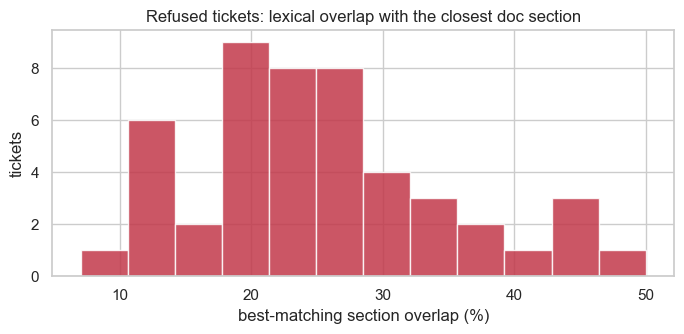

In [27]:
import re  # noqa: E402

refused = responses[responses["chatbot_refused"].astype(str).str.lower() == "true"].copy()
print(f"{len(refused)} / {len(responses)} responses are refusals "
      f"(each will be classified HUMAN by the evaluator rubric)")

_STOP = set("a an the to i want so that of in on for with my our as be can could would how do "
            "does is are was were and or at it this these those able also more new".split())
def _toks(s):
    return {w for w in re.findall(r"[a-z]+", str(s).lower()) if w not in _STOP and len(w) > 2}

_SECS = [(s.title, _toks(s.title + " " + s.body)) for s in knowledge.content_sections()]

def nearest_doc_sections(text, k=3):
    q = _toks(text)
    if not q:
        return "(no content)"
    scored = sorted(((len(q & t) / len(q), title) for title, t in _SECS), reverse=True)
    hits = [f"{title} ({v:.0%})" for v, title in scored[:k] if v > 0]
    return "; ".join(hits) or "(no doc section overlaps)"

refused["nearest_doc_sections"] = refused["summary"].map(nearest_doc_sections)
refused["top_overlap_%"] = (
    refused["nearest_doc_sections"].str.extract(r"\((\d+)%\)").astype(float)
)
display(refused[["ticket_id", "summary", "nearest_doc_sections"]])
print(f"\nMedian best-section overlap for refused tickets: "
      f"{refused['top_overlap_%'].median():.0f}%  — i.e. the documentation simply does not "
      f"describe these feature requests, which is why the bot (correctly) declined.")

if HAVE_PLOTS and len(refused):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(refused["top_overlap_%"].dropna(), bins=12, color="#c2384a", alpha=.85)
    ax.set_title("Refused tickets: lexical overlap with the closest doc section")
    ax.set_xlabel("best-matching section overlap (%)"); ax.set_ylabel("tickets")
    fig.tight_layout(); plt.show()

## Section 6 — Evaluate Responses

A **separate** strict evaluator (`EVALUATOR_MODEL`, its own prompt in
`backtest.EVALUATOR_SYSTEM`) classifies each reply as `FULL` / `PARTIAL` / `HUMAN`. It sees
only *(summary, reply)* — never `historical_resolved`. Appends to
`evaluation/results/evaluations.csv`; resumable.

To spare the daily quota, tickets are judged **`EVAL_BATCH_SIZE` per call** (one request
returns a JSON array of verdicts). Each verdict must echo its `ticket_id`; anything the
batch drops or mislabels is re-judged individually. The evaluator is *our* component, not
the production chatbot, so batching it does not affect chatbot fidelity.

In [28]:
evaluations = bt.run_evaluation(responses, cfg)

if evaluations.empty or "classification" not in evaluations.columns:
    raise SystemExit("No evaluations yet (quota hit before the first batch?). "
                     "Wait for quota to reset, or point EVALUATOR_MODEL at a model "
                     "with quota left in Section 2, then re-run Sections 2 + 6.")

print(evaluations["classification"].value_counts().to_string())

fb = bt._truthy(evaluations.get("evaluator_fallback", pd.Series(dtype=str)))
if fb.any():
    print(f"\nℹ  {fb.sum()} evaluations fell back to HUMAN "
          "(empty reply, or evaluator returned invalid JSON twice).")
    print("   Under LLM_BACKEND=mock this is expected — the mock cannot act as a judge.")

[evaluate] 49 already judged, 1 to judge (model=gemini-flash-latest, 15/call)
[evaluate] call 1: +1 judged (total 50)
classification
HUMAN    48
FULL      2


In [29]:
# Merge into one row per ticket and persist the canonical outputs
results = bt.build_results(tickets, responses, evaluations)
metrics = bt.calculate_metrics(results, cfg)

bt.save_results(results)                       # results/backtest_results.csv
bt.save_metrics(metrics)                       # results/summary_metrics.json
print("wrote evaluation/results/backtest_results.csv  &  summary_metrics.json")
print(f"evaluated {len(results)} / {len(tickets)} tickets")
results.head()

wrote evaluation/results/backtest_results.csv  &  summary_metrics.json
evaluated 33 / 33 tickets


,issue_type,ticket_id,historical_status,historical_resolved,Subject,Type,Description,Type_norm,chatbot_response,chatbot_refused,...,chatbot_model,chatbot_error,latency_s,summary,answered_at,classification,evaluation_reason,evaluator_model,evaluator_fallback,summary_length
0,Story,17973,Done,True,Inventory Item Charge,Staff member,"I want to modify charges that were originally created from an inventory item, so that pricing corrections don't require deleting and rec...",staff member,I don't have enough information in my records to answer that. Please submit a support ticket.,True,...,gemini-3.1-flash-lite,NaN,3.59,"Inventory Item Charge: As a Staff member, I want to modify charges that were originally created from an inventory item, so that pricing ...",2026-09-07T02:52:54+00:00,HUMAN,"The assistant replied that it does not have enough information, which requires human staff intervention.",gemini-flash-latest,False,197
1,Story,17404,Done,True,Encounter List,Staff member,"I want to search and track encounters by Encounter Number with more flexible search options, so that I can locate a specific encounter q...",staff member,I don't have enough information in my records to answer that. Please submit a support ticket.,True,...,gemini-3.1-flash-lite,NaN,1.08,"Encounter List: As a Staff member, I want to search and track encounters by Encounter Number with more flexible search options, so that ...",2026-09-07T02:52:55+00:00,HUMAN,"The assistant stated it lacks enough information to answer, requiring human review.",gemini-flash-latest,False,178
2,Story,17206,Done,True,Financial Dashboard Revamp,Admin,"I want a high-level view of total revenue and operating expenses across all connected healthcare facilities, so that I can monitor finan...",admin,I don't have enough information in my records to answer that. Please submit a support ticket.,True,...,gemini-3.1-flash-lite,NaN,1.09,"Financial Dashboard Revamp: As an Admin, I want a high-level view of total revenue and operating expenses across all connected healthcar...",2026-09-07T02:52:56+00:00,HUMAN,"The assistant replied with a lack of information refusal, requiring human assistance.",gemini-flash-latest,False,205
3,Story,16034,Done,True,Invoice Report Export,User,"I want to apply filters before exporting, so that I only export the invoices I need.",user,I don't have enough information in my records to answer that. Please submit a support ticket.,True,...,gemini-3.1-flash-lite,NaN,1.1,"Invoice Report Export: As a User, I want to apply filters before exporting, so that I only export the invoices I need.",2026-09-07T02:53:01+00:00,HUMAN,"The assistant was unable to answer due to insufficient information, requiring human staff intervention.",gemini-flash-latest,False,118
4,Story,15967,Done,True,Appointment Reschedule,Doctor,"I want to reschedule appointments from any tab and from the off-canvas panel, so that I don't have to navigate to a specific view to mak...",doctor,I don't have enough information in my records to answer that. Please submit a support ticket.,True,...,gemini-3.1-flash-lite,NaN,1.01,"Appointment Reschedule: As a Doctor, I want to reschedule appointments from any tab and from the off-canvas panel, so that I don't have ...",2026-09-07T02:53:02+00:00,HUMAN,"The assistant replied that it lacks information to answer, directing the user to submit a ticket.",gemini-flash-latest,False,186


## Section 7 — Evaluation Results

In [30]:
d  = metrics["potential_deflection_rate"]
pa = metrics["partial_assistance_rate"]
hr = metrics["human_required_rate"]

print("=" * 46)
print(f"  Potential deflection (FULL) : {d:6.1%}   ({metrics['full']})")
print(f"  Partial assistance          : {pa:6.1%}   ({metrics['partial']})")
print(f"  Human required              : {hr:6.1%}   ({metrics['human']})")
print("=" * 46)
print(f"  Tickets evaluated           : {metrics['total_tickets']}")
print(f"  Evaluator fallbacks         : {metrics['evaluator_fallback_count']}")
print(f"  Chatbot errors              : {metrics['chatbot_error_count']}")
bt.breakdown_table(results)

  Potential deflection (FULL) :   6.1%   (2)
  Partial assistance          :   0.0%   (0)
  Human required              :  93.9%   (31)
  Tickets evaluated           : 33
  Evaluator fallbacks         : 0
  Chatbot errors              : 0


,classification,count,percent
0,FULL,2,6.1
1,PARTIAL,0,0.0
2,HUMAN,31,93.9


### Graph 1 — Potential automation breakdown

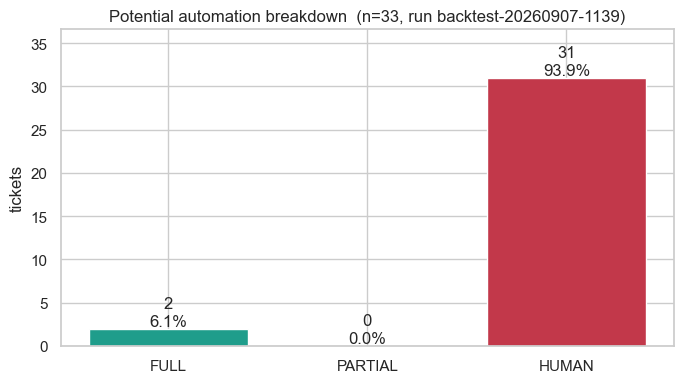

In [13]:
if HAVE_PLOTS:
    bd = bt.breakdown_table(results)
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(bd["classification"], bd["count"],
                  color=["#1f9d8b", "#e0a100", "#c2384a"])
    for b, pct in zip(bars, bd["percent"]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{int(b.get_height())}\n{pct:.1f}%", ha="center", va="bottom")
    ax.set_title(f"Potential automation breakdown  (n={len(results)}, run {RUN_ID})")
    ax.set_ylabel("tickets"); ax.margins(y=.18)
    fig.tight_layout(); plt.show()

### Graph 2 — Potential deflection rate

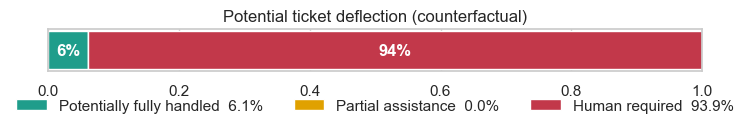

In [31]:
if HAVE_PLOTS:
    fig, ax = plt.subplots(figsize=(8, 1.8))
    left = 0
    for label, val, col in [("Potentially fully handled", d, "#1f9d8b"),
                            ("Partial assistance", pa, "#e0a100"),
                            ("Human required", hr, "#c2384a")]:
        ax.barh([0], [val], left=left, color=col, label=f"{label}  {val:.1%}")
        if val > 0.04:
            ax.text(left + val / 2, 0, f"{val:.0%}", ha="center", va="center",
                    color="white", fontweight="bold")
        left += val
    ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_title("Potential ticket deflection (counterfactual)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)
    fig.tight_layout(); plt.show()

### Graph 3 — Historical resolution vs chatbot classification

**Exploratory only.** `historical_resolved` records what humans did, not whether the bot
*could* have handled the ticket. Do not read causation into this.

historical_resolved,resolved
classification,
FULL,2
PARTIAL,0
HUMAN,31


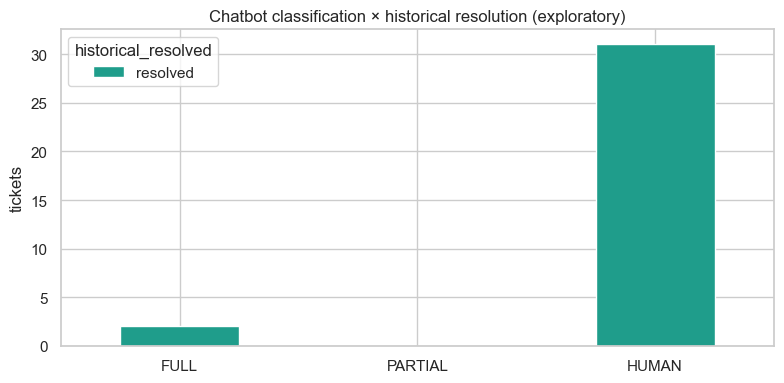

In [32]:
ct = bt.resolved_crosstab(results)
if ct is None:
    print("dataset has no `resolved` column — skipping")
else:
    display(ct)
    if HAVE_PLOTS:
        ax = ct.plot.bar(figsize=(8, 4), color=["#1f9d8b", "#c2384a"])
        ax.set_title("Chatbot classification × historical resolution (exploratory)")
        ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0); ax.set_ylabel("tickets")
        plt.tight_layout(); plt.show()

### Graph 4 — Summary length vs classification

C:\Users\windows 10\AppData\Local\Temp\ipykernel_10360\4284820890.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lv, x="classification", y="summary_length", order=order,
C:\Users\windows 10\AppData\Local\Temp\ipykernel_10360\4284820890.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=lv, x="classification", y="summary_length", order=order,


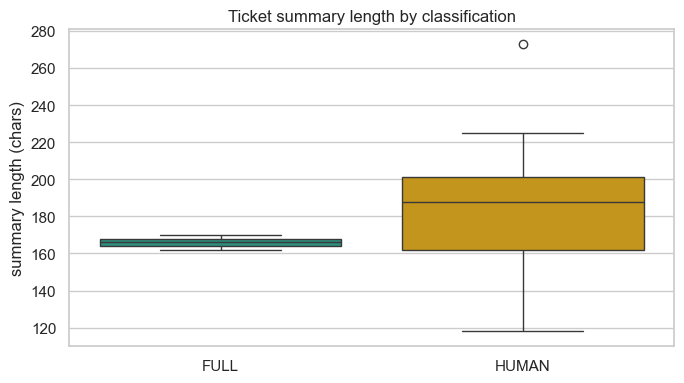

In [33]:
if HAVE_PLOTS:
    lv = bt.length_vs_classification(results)
    order = [x for x in bt.CLASSIFICATIONS if x in lv["classification"].unique()]
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=lv, x="classification", y="summary_length", order=order,
                palette=["#1f9d8b", "#e0a100", "#c2384a"], ax=ax)
    ax.set_title("Ticket summary length by classification")
    ax.set_xlabel(""); ax.set_ylabel("summary length (chars)")
    fig.tight_layout(); plt.show()

### Graph 5 — Classification by ticket category

Only runs if the dataset actually carries a categorical field (`issue_type`, `priority`,
`category`, `project`). Nothing is fabricated.


=== deflection by Type_norm ===


classification,FULL,PARTIAL,HUMAN,total,deflection_%
Type_norm,,,,,
staff member,1,0,17,18,5.6
admin,0,0,4,4,0.0
user,0,0,3,3,0.0
administrator,1,0,0,1,100.0
accountant or finance user,0,0,1,1,0.0
company user,0,0,1,1,0.0
doctor,0,0,1,1,0.0
facility staff member,0,0,1,1,0.0
facility admin,0,0,1,1,0.0


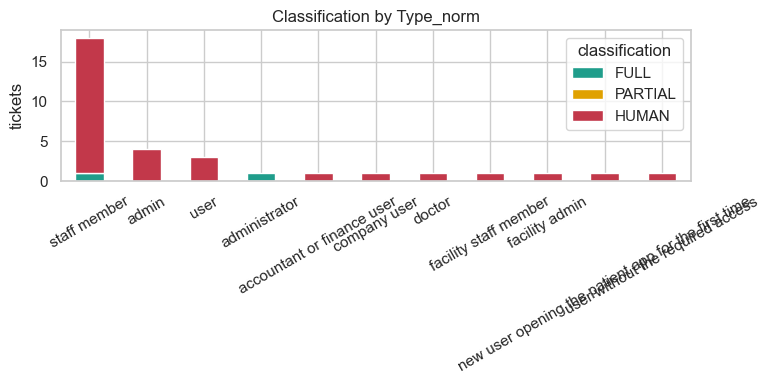


=== deflection by issue_type ===


classification,FULL,PARTIAL,HUMAN,total,deflection_%
issue_type,,,,,
Story,2,0,31,33,6.1


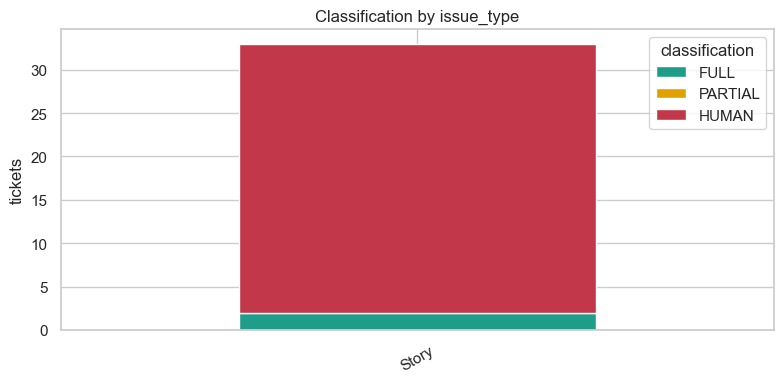

In [34]:
cat_cols = [x for x in ("Type_norm", "issue_type", "priority", "category", "project")
            if x in results.columns and results[x].astype(str).str.strip().ne("").any()]
for col in cat_cols:
    tbl = bt.by_category(results, col)
    if tbl is None:
        continue
    print(f"\n=== deflection by {col} ===")
    display(tbl)
    if HAVE_PLOTS:
        ax = tbl[list(bt.CLASSIFICATIONS)].plot.bar(
            stacked=True, figsize=(8, 4), color=["#1f9d8b", "#e0a100", "#c2384a"])
        ax.set_title(f"Classification by {col}"); ax.set_xlabel(""); ax.set_ylabel("tickets")
        ax.tick_params(axis="x", rotation=30); plt.tight_layout(); plt.show()
if not cat_cols:
    print("no categorical metadata columns present — skipping")

## Section 8 — Manual Validation Sample & Evaluator Agreement

The headline metric relies on an LLM judging an LLM. This section exports a random sample
for a **human** to label independently, then (once labels are filled in) measures agreement.

In [35]:
MANUAL_SAMPLE_SIZE = 50

sample = bt.sample_for_manual_review(results, n=MANUAL_SAMPLE_SIZE, seed=42)
print(f"wrote evaluation/results/manual_review_sample.csv  ({len(sample)} rows)")
print("Fill the `human_evaluation` column with FULL / PARTIAL / HUMAN (and `human_reason`),")
print("save the file, then run the next cell.")
sample.head()

wrote evaluation/results/manual_review_sample.csv  (33 rows)
Fill the `human_evaluation` column with FULL / PARTIAL / HUMAN (and `human_reason`),
save the file, then run the next cell.


,ticket_id,summary,chatbot_response,llm_evaluation,llm_reason,human_evaluation,human_reason,judge_correct
31,10525,"Insurance Claims Access Restriction: As a User without the required access, I should not be able to view the Claims module, so that insu...",I don't have enough information in my records to answer that. Please submit a support ticket.,HUMAN,"The assistant refused the query citing insufficient information, which automatically classifies it as requiring human assistance.",,,
15,15472,"Payee Management: As an Accountant or Finance user, I want to be required to enter a TIN and Address, with a warning shown if either is ...",I don't have enough information in my records to answer that. Please submit a support ticket.,HUMAN,"The assistant offered a 'not enough information' refusal, requiring human action.",,,
26,12865,"Onboarding: As a new user opening the Patient App for the first time, I want to see a series of onboarding welcome screens, so that I un...",I don't have enough information in my records to answer that. Please submit a support ticket.,HUMAN,The assistant explicitly states it does not have enough information and directs the user to submit a support ticket.,,,
17,15317,"Staff Management Notification: As a Staff member, I want to view my phone credentials after an Admin registers my account, so that I can...",I don't have enough information in my records to answer that. Please submit a support ticket.,HUMAN,"The assistant provided a refusal citing lack of information, which necessitates human review.",,,
8,15740,"Patient Related Person: As a Staff member, I want to add a Related Person using only their Name and Relationship to the patient, so that...",I don't have enough information in my records to answer that. Please submit a support ticket.,HUMAN,The assistant stated it does not have enough information to address the ticket.,,,


In [36]:
review_path = bt.RESULTS_DIR / "manual_review_sample.csv"
reviewed = pd.read_csv(review_path, dtype=str).fillna("")

# Fill the `judge_correct` column (yes/no per row where a human label exists) and
# write it back so the reviewed CSV records where the LLM judge was right/wrong.
reviewed = bt.score_manual_review(reviewed)
reviewed.to_csv(review_path, index=False)

agreement = bt.evaluator_agreement(reviewed)

if agreement.get("reviewed", 0) == 0:
    print("No human labels found yet — fill in `human_evaluation` and re-run.")
    display(reviewed[["ticket_id", "llm_evaluation", "human_evaluation", "judge_correct"]].head())
else:
    print(f"Human-labelled rows : {agreement['reviewed']}")
    print(f"LLM judge correct   : {agreement['judge_correct']} / {agreement['reviewed']}"
          f"  ({agreement['agreement_rate']:.1%})")
    print(f"LLM judge wrong     : {agreement['judge_incorrect']}")
    print(f"Cohen's kappa       : {agreement['cohens_kappa']:.3f}")
    print("\nPer-row verdict (judge_correct):")
    display(reviewed.loc[reviewed["judge_correct"] != "",
                         ["ticket_id", "summary", "llm_evaluation", "human_evaluation",
                          "judge_correct"]])
    print("Confusion matrix (rows = human, cols = LLM):")
    display(agreement["confusion_matrix"])
    metrics["manual_validation"] = {k: v for k, v in agreement.items()
                                    if k != "confusion_matrix"}
    bt.save_metrics(metrics)
    if HAVE_PLOTS:
        fig, ax = plt.subplots(figsize=(4.5, 3.8))
        sns.heatmap(agreement["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax)
        ax.set_xlabel("LLM evaluator"); ax.set_ylabel("human"); ax.set_title("Evaluator agreement")
        fig.tight_layout(); plt.show()

No human labels found yet — fill in `human_evaluation` and re-run.


,ticket_id,llm_evaluation,human_evaluation,judge_correct
0,10525,HUMAN,,
1,15472,HUMAN,,
2,12865,HUMAN,,
3,15317,HUMAN,,
4,15740,HUMAN,,


## Section 9 — Qualitative Analysis

In [20]:
for label in bt.CLASSIFICATIONS:
    ex = bt.examples_by_class(results, label, n=3, seed=7)
    print(f"\n{'='*70}\n{label}  —  {len(results[results['classification']==label])} tickets\n{'='*70}")
    for _, r in ex.iterrows():
        print(f"\n[{r['ticket_id']}]  {r['summary']}")
        print(f"  chatbot : {str(r['chatbot_response'])[:280]}")
        print(f"  reason  : {r['evaluation_reason']}")


FULL  —  2 tickets

[13591]  Document Template Enhancement: As a Staff member, I want to customize the header location on document templates, so that documents match each facility's preferred layout.
  chatbot : To customize the header on document templates, follow these steps from the **Facility Settings — Document Templates** section:

1. Sidebar → **Facility Settings** → **Document Templates**.
2. Select a **practitioner** from the drop-down.
3. Choose the **record** to configure (sel
  reason  : The assistant provides clear, step-by-step instructions on how to navigate to and configure the document template headers in Facility Settings.

[10523]  Facility Initial Setup: As an Administrator, I want to set up the facility, so that staff can start using the system to manage operational and healthcare records.
  chatbot : To set up your facility as an Administrator, you should follow these modules in the order provided in the documentation to ensure your staff can manage records effec

## Section 10 — Failure Analysis

Coarse, **rule-based** tagging of the evaluator's reason text for `HUMAN` / `PARTIAL`
tickets — kept deliberately separate from the primary classification and using **no extra
model call**.

,patterns,count
0,insufficient_information,31
1,requires_manual_change,2


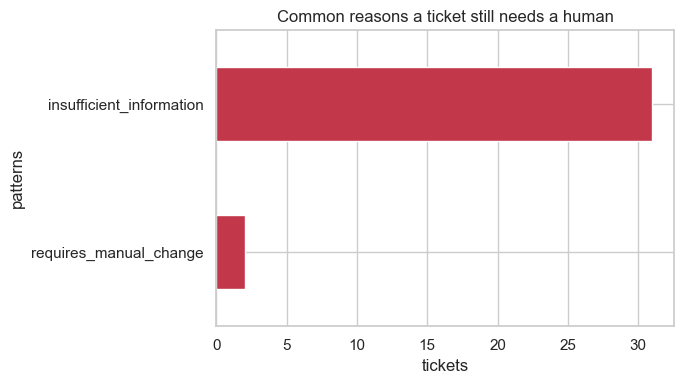

In [37]:
fp = bt.failure_patterns(results)
if fp.empty:
    print("no HUMAN/PARTIAL tickets to analyse")
else:
    display(fp)
    if HAVE_PLOTS:
        ax = fp.set_index("patterns")["count"].plot.barh(figsize=(7, 4), color="#c2384a")
        ax.invert_yaxis(); ax.set_title("Common reasons a ticket still needs a human")
        ax.set_xlabel("tickets"); plt.tight_layout(); plt.show()

## Section 11 — Output Files

In [38]:
for name in ("backtest_results.csv", "manual_review_sample.csv", "summary_metrics.json",
             "chatbot_responses.csv", "evaluations.csv"):
    p = bt.RESULTS_DIR / name
    print(f"  {'✓' if p.exists() else '·'}  {p.relative_to(ROOT)}"
          f"{'  ' + f'{p.stat().st_size:,} B' if p.exists() else ''}")
print("\nsummary_metrics.json:")
print(json.dumps(json.loads((bt.RESULTS_DIR / 'summary_metrics.json').read_text()), indent=2))

  ✓  evaluation\results\backtest_results.csv  27,761 B
  ✓  evaluation\results\manual_review_sample.csv  16,045 B
  ✓  evaluation\results\summary_metrics.json  1,049 B
  ✓  evaluation\results\chatbot_responses.csv  23,619 B
  ✓  evaluation\results\evaluations.csv  9,605 B

summary_metrics.json:
{
  "total_tickets": 33,
  "full": 2,
  "partial": 0,
  "human": 31,
  "potential_deflection_rate": 0.0606,
  "partial_assistance_rate": 0.0,
  "human_required_rate": 0.9394,
  "evaluator_fallback_count": 0,
  "chatbot_error_count": 0,
  "historical_resolved_true": 33,
  "historical_resolved_false": 0,
  "run": {
    "run_id": "backtest-20260907-1142",
    "chatbot_model": "gemini-3.1-flash-lite",
    "evaluator_model": "gemini-flash-latest",
    "batch_size": 50,
    "eval_batch_size": 15,
    "evaluator_temperature": 0.0,
    "max_workers": 1,
    "limit": null,
    "started_at": "2026-09-07T03:42:06+00:00",
    "prod_answer_model": "gemini-3.1-flash-lite",
    "prod_utility_model": "gemini-3.

## Section 12 — Final Summary

In [39]:
man = metrics.get("manual_validation", {})
print(f'''
Jira Chatbot Historical Backtest
================================

Run ID           : {RUN_ID}
Chatbot model    : {metrics["run"]["chatbot_model"]}   (production, unmodified)
Evaluator model  : {metrics["run"]["evaluator_model"]}
Tickets evaluated: {metrics["total_tickets"]:,}

Potentially fully handled : {metrics["potential_deflection_rate"]:.1%}   ({metrics["full"]})
Partially assistable      : {metrics["partial_assistance_rate"]:.1%}   ({metrics["partial"]})
Human required            : {metrics["human_required_rate"]:.1%}   ({metrics["human"]})

>>> Potential ticket deflection: {metrics["potential_deflection_rate"]:.1%} <<<
    (counterfactual estimate from historical backtesting — NOT a production automation rate)

Manual validation agreement: {(str(round(man["agreement_rate"]*100,1)) + "%  (kappa " + str(man["cohens_kappa"]) + ", n=" + str(man["reviewed"]) + ")") if man else "not yet run — see Section 8"}
''')

print('''Interpretation
--------------
This estimates the SHARE OF TICKETS the chatbot MIGHT have closed unaided, given only each
ticket's opening summary and today's knowledge base.

It does NOT show that the chatbot would have deflected this fraction in production. Missing:
real multi-turn conversations, the docs as they were at the time, user willingness to
self-serve, and an independent check that the LLM evaluator matches human judgement beyond
the Section 8 sample. Treat the deflection figure as an upper-ish planning estimate to be
confirmed with a live A/B test, and always quote it with the manual-agreement number.''')


Jira Chatbot Historical Backtest

Run ID           : backtest-20260907-1142
Chatbot model    : gemini-3.1-flash-lite   (production, unmodified)
Evaluator model  : gemini-flash-latest
Tickets evaluated: 33

Potentially fully handled : 6.1%   (2)
Partially assistable      : 0.0%   (0)
Human required            : 93.9%   (31)

>>> Potential ticket deflection: 6.1% <<<
    (counterfactual estimate from historical backtesting — NOT a production automation rate)

Manual validation agreement: not yet run — see Section 8

Interpretation
--------------
This estimates the SHARE OF TICKETS the chatbot MIGHT have closed unaided, given only each
ticket's opening summary and today's knowledge base.

It does NOT show that the chatbot would have deflected this fraction in production. Missing:
real multi-turn conversations, the docs as they were at the time, user willingness to
self-serve, and an independent check that the LLM evaluator matches human judgement beyond
the Section 8 sample. Treat the de